# ODD + OOD Detection for Safe Autonomy
**Camera-based safety gate for autonomous driving**

- **Input**: Front camera frame
- **Output**: "Trust / Abstain" gate decision
- **ODD**: Daytime + Clear weather + Urban/Highway
- **OOD buckets**: Night, Rain, Fog/Snow

**Members**: Tharun Reddy Challabotla, HariChandana Srikurmum, Srija

## 1. Setup & Installation

In [1]:
# Install dependencies
!pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm kaggle timm open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.5 MB/s eta 0:00:00


In [2]:
# Run this in a new cell at the top of Colab
!pip install -q kaggle

import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

from google.colab import files
print('Upload kaggle.json:')
uploaded = files.upload()

kaggle_path = os.path.expanduser('~/.kaggle/kaggle.json')
with open(kaggle_path, 'w') as f:
    f.write(list(uploaded.values())[0].decode())
os.chmod(kaggle_path, 0o600)

!kaggle datasets download marquis03/bdd100k-weather-classification \
    -p /content/data/raw/bdd100k --unzip

Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/marquis03/bdd100k-weather-classification
License(s): apache-2.0
100% 5.27G/5.27G [05:33<00:00, 17.0MB/s]



In [3]:
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay
)
import timm
import open_clip
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Dataset Download (BDD100K via Kaggle — Fast)

Upload your `kaggle.json` when prompted. This downloads the **weather-classified BDD100K** (~5.3 GB) directly as a zip — much faster than Hugging Face streaming.

In [4]:
# Setup Kaggle credentials
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# For local environment, kaggle.json should already be configured
kaggle_path = os.path.expanduser('~/.kaggle/kaggle.json')
if os.path.exists(kaggle_path):
    print('Kaggle credentials already present.')
else:
    print('Warning: Kaggle credentials not found. Set up ~/.kaggle/kaggle.json if needed.')

Kaggle credentials already present.


In [5]:
%%time
# Use local data directory (already downloaded)
DATA_ROOT = Path('/content/data')
BDD_RAW = DATA_ROOT / 'raw' / 'bdd100k'

if BDD_RAW.exists():
    print(f'BDD100K data found at {BDD_RAW}')
    # Show what we got
    for split in ['train', 'val']:
        split_dir = BDD_RAW / split
        if split_dir.exists():
            folders = [f.name for f in split_dir.iterdir() if f.is_dir()]
            print(f'{split}: {folders}')
else:
    print(f'BDD100K not found at {BDD_RAW}')

BDD100K data found at /content/data/raw/bdd100k
train: ['clear', 'rainy', 'unknown', 'overcast', 'snowy', 'partly cloudy', 'foggy']
val: ['clear', 'rainy', 'unknown', 'overcast', 'snowy', 'partly cloudy', 'foggy']
CPU times: user 1.35 ms, sys: 0 ns, total: 1.35 ms
Wall time: 1.15 ms


## 3. Organize into ODD / OOD Buckets

In [6]:
# Weather folder -> ODD/OOD mapping
WEATHER_BUCKET = {
    'clear': 'in_odd',
    'overcast': 'in_odd',
    'partly cloudy': 'in_odd',
    'rainy': 'rain',
    'foggy': 'fog_snow',
    'snowy': 'fog_snow',
    # 'unknown' -> skip
}

def collect_image_paths(bdd_raw, weather_bucket_map):
    """Collect all image paths organized by bucket."""
    buckets = {'in_odd': [], 'rain': [], 'fog_snow': []}
    img_ext = {'.jpg', '.jpeg', '.png'}

    for split in ['train', 'val']:
        split_dir = bdd_raw / split
        if not split_dir.exists():
            continue
        for weather_name, bucket in weather_bucket_map.items():
            folder = split_dir / weather_name
            if not folder.exists():
                continue
            for img in folder.iterdir():
                if img.suffix.lower() in img_ext:
                    buckets[bucket].append((str(img), split))

    return buckets

buckets = collect_image_paths(BDD_RAW, WEATHER_BUCKET)

print('=== Dataset Bucket Summary ===')
for name, paths in buckets.items():
    splits = Counter(s for _, s in paths)
    print(f'  {name:>10}: {len(paths):>6} images  (train={splits["train"]}, val={splits["val"]})')
print(f'  {"TOTAL":>10}: {sum(len(v) for v in buckets.values()):>6} images')

=== Dataset Bucket Summary ===
      in_odd:  58318 images  (train=50995, val=7323)
        rain:   5808 images  (train=5070, val=738)
    fog_snow:   6461 images  (train=5679, val=782)
       TOTAL:  70587 images


## 4. Dataset & DataLoaders

Binary classification: **In-ODD (label=0)** vs **OOD (label=1)**. We combine rain + fog_snow as OOD for training, then evaluate per-type separately.

In [7]:
class ODD_OOD_Dataset(Dataset):
    """Binary ODD/OOD dataset from pre-collected image paths."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# Transforms — works for all backbones (224x224)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [8]:
def build_splits(buckets, max_in_odd=20000, max_ood_per_type=5000):
    """
    Build balanced train/val splits.
    Use more data for better feature learning.
    """
    train_paths, train_labels = [], []
    val_paths, val_labels = [], []
    val_ood_types = []

    # In-ODD (label=0)
    in_odd_train = [p for p, s in buckets['in_odd'] if s == 'train']
    in_odd_val = [p for p, s in buckets['in_odd'] if s == 'val']
    random.shuffle(in_odd_train)
    random.shuffle(in_odd_val)
    in_odd_train = in_odd_train[:max_in_odd]
    in_odd_val = in_odd_val[:max_in_odd // 4]

    train_paths.extend(in_odd_train)
    train_labels.extend([0] * len(in_odd_train))
    val_paths.extend(in_odd_val)
    val_labels.extend([0] * len(in_odd_val))
    val_ood_types.extend(['in_odd'] * len(in_odd_val))

    # OOD types (label=1)
    for ood_type in ['rain', 'fog_snow']:
        ood_train = [p for p, s in buckets[ood_type] if s == 'train']
        ood_val = [p for p, s in buckets[ood_type] if s == 'val']
        random.shuffle(ood_train)
        random.shuffle(ood_val)
        ood_train = ood_train[:max_ood_per_type]
        ood_val = ood_val[:max_ood_per_type // 4]

        train_paths.extend(ood_train)
        train_labels.extend([1] * len(ood_train))
        val_paths.extend(ood_val)
        val_labels.extend([1] * len(ood_val))
        val_ood_types.extend([ood_type] * len(ood_val))

    return (train_paths, train_labels), (val_paths, val_labels), val_ood_types


(train_paths, train_labels), (val_paths, val_labels), val_ood_types = build_splits(buckets)

train_ds = ODD_OOD_Dataset(train_paths, train_labels, train_transform)
val_ds = ODD_OOD_Dataset(val_paths, val_labels, val_transform)

BATCH_SIZE = 64
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_ds)} images ({Counter(train_labels)})')
print(f'Val:   {len(val_ds)} images ({Counter(val_labels)})')
print(f'Batches per epoch: {len(train_loader)}')

Train: 30000 images (Counter({0: 20000, 1: 10000}))
Val:   6520 images (Counter({0: 5000, 1: 1520}))
Batches per epoch: 468


## 5. Multi-Backbone Architecture — ResNet-50, EfficientNet-B3, ConvNeXt-Tiny, CLIP ViT-B/16

We compare 4 backbone architectures plus a zero-shot CLIP approach for weather-based OOD detection.

In [9]:
class SafetyGateModel(nn.Module):
    """
    Multi-backbone safety gate model.
    Supports: resnet50, efficientnet_b3, convnext_tiny, clip_vitb16
    """

    def __init__(self, backbone_name='resnet50', num_classes=2, dropout_rate=0.3):
        super().__init__()
        self.backbone_name = backbone_name

        if backbone_name == 'resnet50':
            backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
            self.frozen_layers = nn.Sequential(
                backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
                backbone.layer1, backbone.layer2,
            )
            self.finetune_layers = nn.Sequential(
                backbone.layer3, backbone.layer4,
            )
            self.avgpool = backbone.avgpool
            feat_dim = 2048

        elif backbone_name == 'efficientnet_b3':
            backbone = timm.create_model('efficientnet_b3', pretrained=True, features_only=False)
            features = list(backbone.blocks.children())
            split_at = 4
            self.frozen_layers = nn.Sequential(backbone.conv_stem, backbone.bn1,
                                               *features[:split_at])
            self.finetune_layers = nn.Sequential(*features[split_at:],
                                                  backbone.conv_head, backbone.bn2)
            self.avgpool = nn.AdaptiveAvgPool2d(1)
            feat_dim = 1536

        elif backbone_name == 'convnext_tiny':
            backbone = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
            stages = list(backbone.features.children())
            split_at = 4
            self.frozen_layers = nn.Sequential(*stages[:split_at])
            self.finetune_layers = nn.Sequential(*stages[split_at:])
            self.avgpool = nn.AdaptiveAvgPool2d(1)
            feat_dim = 768

        elif backbone_name == 'clip_vitb16':
            clip_model, _, _ = open_clip.create_model_and_transforms(
                'ViT-B-16', pretrained='laion2b_s34b_b88k'
            )
            self.clip_visual = clip_model.visual
            # Freeze early transformer blocks (first 8 of 12)
            # Freeze patch embedding + positional embedding
            for param in self.clip_visual.conv1.parameters():
                param.requires_grad = False
            self.clip_visual.class_embedding.requires_grad = False
            self.clip_visual.positional_embedding.requires_grad = False
            # Freeze first 8 transformer blocks
            for i, block in enumerate(self.clip_visual.transformer.resblocks):
                if i < 8:
                    for param in block.parameters():
                        param.requires_grad = False
                else:
                    for param in block.parameters():
                        param.requires_grad = True
            # Fine-tune ln_post and proj
            if self.clip_visual.proj is not None:
                self.clip_visual.proj.requires_grad = True

            # Dummy layers for compatibility
            self.frozen_layers = nn.Identity()
            self.finetune_layers = nn.Identity()
            self.avgpool = nn.Identity()
            feat_dim = 512

        else:
            raise ValueError(f'Unknown backbone: {backbone_name}')

        # MLP head with BatchNorm
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes),
        )

    def features(self, x):
        if self.backbone_name == 'clip_vitb16':
            return self.clip_visual(x)
        else:
            with torch.no_grad():
                x = self.frozen_layers(x)
            x = self.finetune_layers(x)
            x = self.avgpool(x)
            return x.flatten(1)

    def forward(self, x):
        feats = self.features(x)
        return self.head(feats)

    def get_features(self, x):
        return self.features(x).detach()


# ─── Print all backbone info ───
BACKBONE_NAMES = ['resnet50', 'efficientnet_b3', 'convnext_tiny', 'clip_vitb16']

for bname in BACKBONE_NAMES:
    m = SafetyGateModel(backbone_name=bname).to('cpu')
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{bname:<20} | Total: {total:>12,} | Trainable: {trainable:>10,} ({100*trainable/total:.1f}%)')
    del m

print(f'\nAll 4 architectures loaded successfully!')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 154MB/s]


resnet50             | Total:   24,624,322 | Trainable: 24,624,322 (100.0%)


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

efficientnet_b3      | Total:   11,550,378 | Trainable: 11,550,378 (100.0%)
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 244MB/s] 


convnext_tiny        | Total:   28,279,522 | Trainable: 28,279,522 (100.0%)


open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

clip_vitb16          | Total:   86,522,498 | Trainable: 29,077,634 (33.6%)

All 4 architectures loaded successfully!


## 6. Train All Backbones & Compare

In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc='Val', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

In [11]:
# Training config
NUM_EPOCHS = 25
LR_HEAD = 1e-3
LR_BACKBONE = 1e-4
LR_CLIP = 2e-5  # even lower for CLIP — pretrained on 2B images

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def lr_lambda(epoch):
    warmup_epochs = 3
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (NUM_EPOCHS - warmup_epochs)
    return 0.5 * (1 + np.cos(np.pi * progress))


def train_backbone(backbone_name, train_loader, val_loader, num_epochs=NUM_EPOCHS):
    """Train a single backbone model end-to-end."""
    print(f'\n{"="*65}')
    print(f'  TRAINING: {backbone_name.upper()}')
    print(f'{"="*65}')

    model = SafetyGateModel(backbone_name=backbone_name).to(DEVICE)

    # Build optimizer param groups based on backbone type
    if backbone_name == 'clip_vitb16':
        # CLIP: fine-tune last 4 transformer blocks + proj + head
        clip_finetune_params = []
        for i, block in enumerate(model.clip_visual.transformer.resblocks):
            if i >= 8:
                clip_finetune_params.extend(block.parameters())
        if model.clip_visual.proj is not None:
            clip_finetune_params.append(model.clip_visual.proj)
        if hasattr(model.clip_visual, 'ln_post'):
            clip_finetune_params.extend(model.clip_visual.ln_post.parameters())

        optimizer = torch.optim.AdamW([
            {'params': clip_finetune_params, 'lr': LR_CLIP},
            {'params': model.head.parameters(), 'lr': LR_HEAD},
        ], weight_decay=1e-4)
    else:
        optimizer = torch.optim.AdamW([
            {'params': model.finetune_layers.parameters(), 'lr': LR_BACKBONE},
            {'params': model.head.parameters(), 'lr': LR_HEAD},
        ], weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        tag = ''
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{backbone_name}.pth')
            tag = ' *best*'

        if epoch % 5 == 0 or epoch == num_epochs or tag:
            print(f'  Epoch {epoch:2d}/{num_epochs} | '
                  f'Train Loss={train_loss:.4f} Acc={train_acc:.4f} | '
                  f'Val Loss={val_loss:.4f} Acc={val_acc:.4f}{tag}')

    model.load_state_dict(torch.load(f'best_{backbone_name}.pth', weights_only=True))
    print(f'  Best Val Accuracy: {best_val_acc:.4f}')
    return model, history, best_val_acc


# ─── Train all 4 backbones ───
all_models = {}
all_histories = {}
all_best_accs = {}

for backbone_name in BACKBONE_NAMES:
    model, history, best_acc = train_backbone(backbone_name, train_loader, val_loader)
    all_models[backbone_name] = model
    all_histories[backbone_name] = history
    all_best_accs[backbone_name] = best_acc

# Pick the best backbone
best_backbone = max(all_best_accs, key=all_best_accs.get)
model = all_models[best_backbone]

print(f'\n{"="*65}')
print(f'  BACKBONE COMPARISON')
print(f'{"="*65}')
for name, acc in all_best_accs.items():
    marker = ' <-- BEST' if name == best_backbone else ''
    print(f'  {name:<20} Val Acc = {acc:.4f}{marker}')
print(f'\nUsing {best_backbone} for OOD detection.')


  TRAINING: RESNET50


Train:   0%|          | 0/468 [00:00<?, ?it/s]

Val:   0%|          | 0/102 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ac9d8595080>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7ac9d8595080>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():
^ ^^ 

  Epoch  1/25 | Train Loss=0.4669 Acc=0.8289 | Val Loss=0.3758 Acc=0.8890 *best*


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ac9d8595080>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
   Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7ac9d8595080>  
 Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    if w.is_alive():
 ^ ^ ^ ^  ^ 
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^ ^^ ^ 
    File "/usr/li

Val:   0%|          | 0/102 [00:00<?, ?it/s]

Train:   0%|          | 0/468 [00:00<?, ?it/s]

Val:   0%|          | 0/102 [00:00<?, ?it/s]

  Epoch 25/25 | Train Loss=0.2327 Acc=0.9822 | Val Loss=0.3613 Acc=0.9252
  Best Val Accuracy: 0.9359

  BACKBONE COMPARISON
  resnet50             Val Acc = 0.9253
  efficientnet_b3      Val Acc = 0.8975
  convnext_tiny        Val Acc = 0.9368 <-- BEST
  clip_vitb16          Val Acc = 0.9359

Using convnext_tiny for OOD detection.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

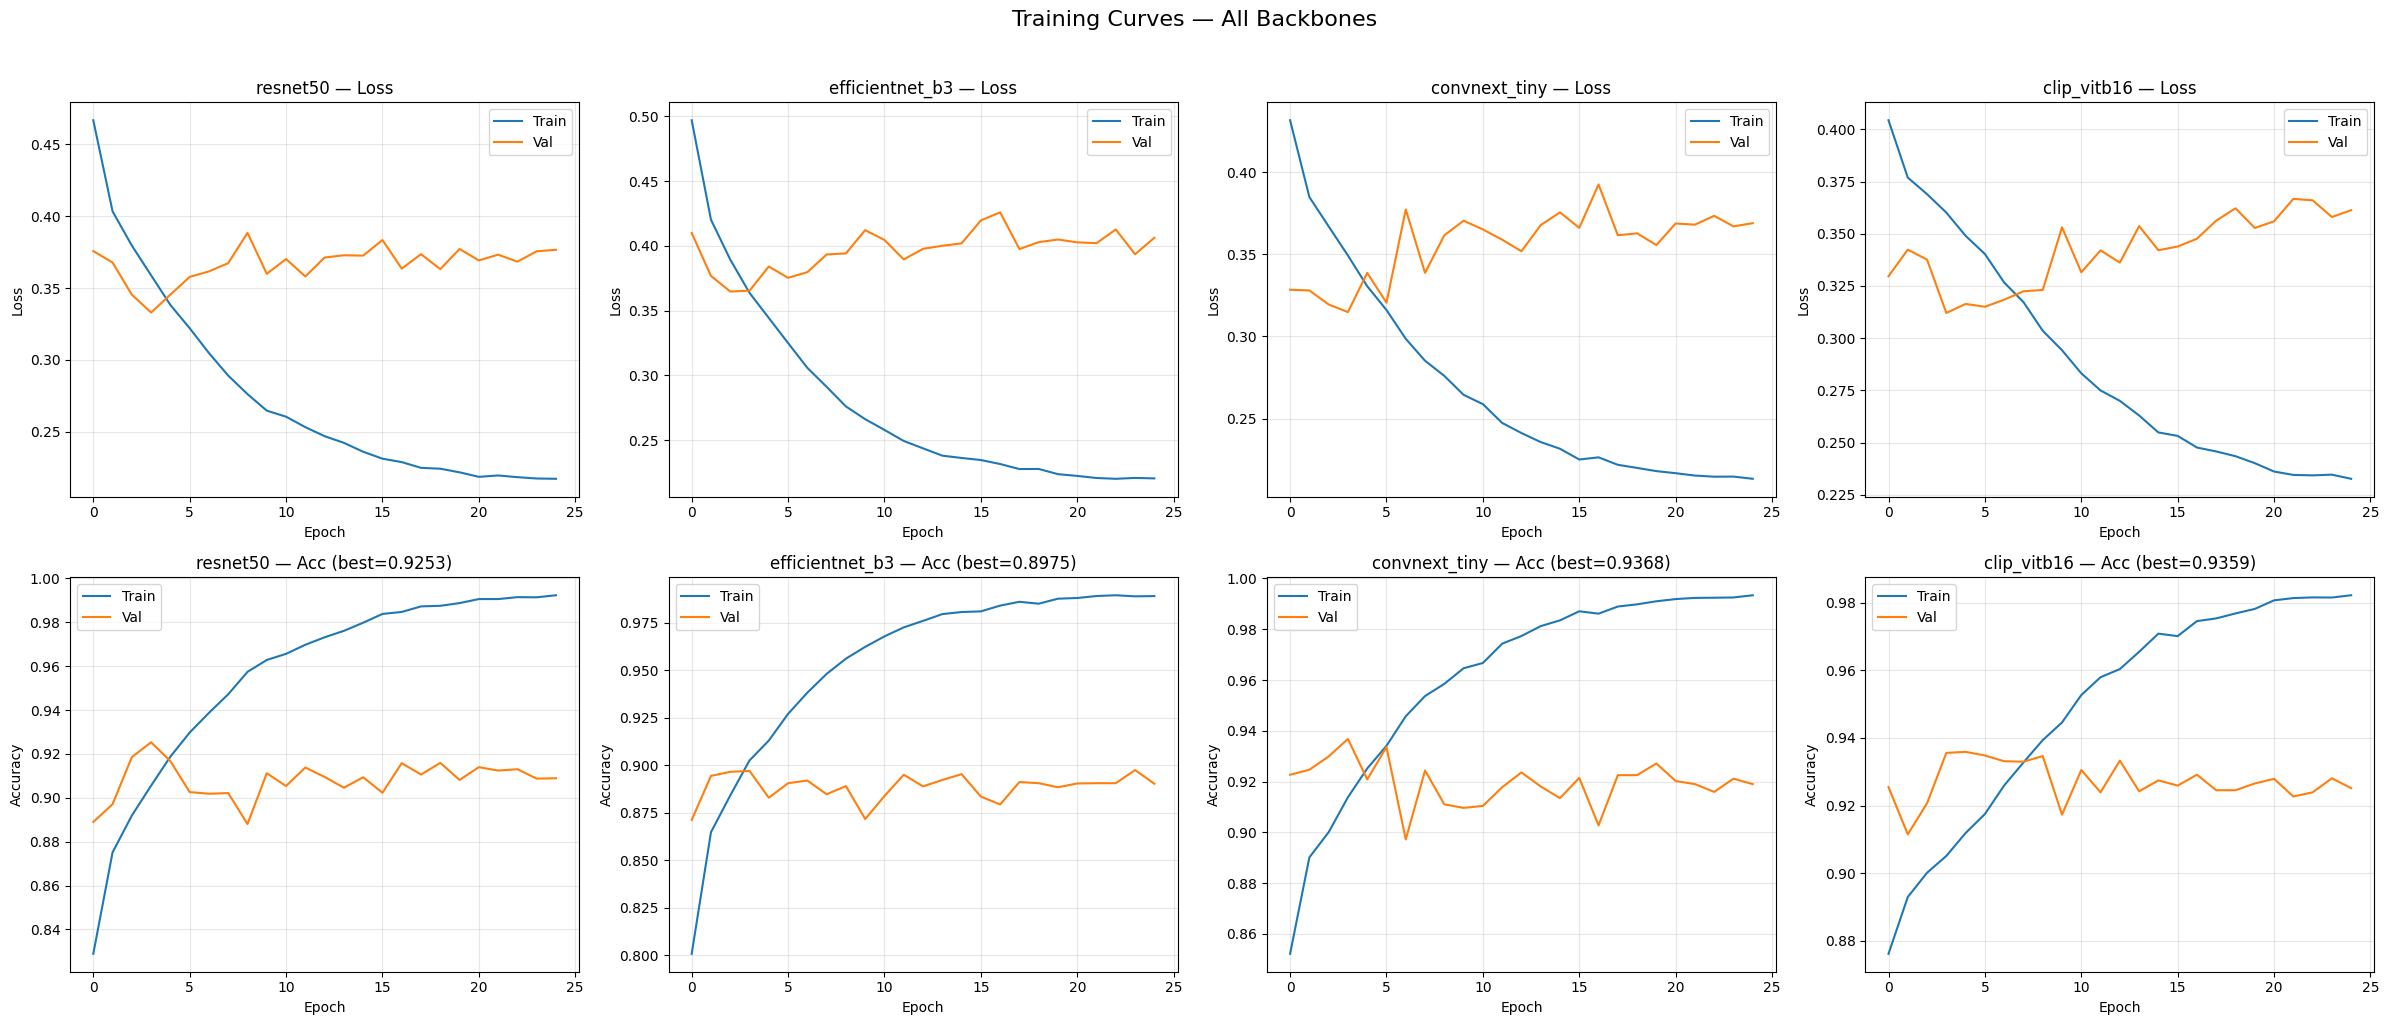

In [12]:
# Plot training curves for all backbones
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

for i, backbone_name in enumerate(BACKBONE_NAMES):
    h = all_histories[backbone_name]

    axes[0][i].plot(h['train_loss'], label='Train')
    axes[0][i].plot(h['val_loss'], label='Val')
    axes[0][i].set_xlabel('Epoch'); axes[0][i].set_ylabel('Loss')
    axes[0][i].set_title(f'{backbone_name} — Loss')
    axes[0][i].legend(); axes[0][i].grid(True, alpha=0.3)

    axes[1][i].plot(h['train_acc'], label='Train')
    axes[1][i].plot(h['val_acc'], label='Val')
    axes[1][i].set_xlabel('Epoch'); axes[1][i].set_ylabel('Accuracy')
    axes[1][i].set_title(f'{backbone_name} — Acc (best={all_best_accs[backbone_name]:.4f})')
    axes[1][i].legend(); axes[1][i].grid(True, alpha=0.3)

plt.suptitle('Training Curves — All Backbones', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. OOD Scoring Methods

We compare five scoring approaches plus **Zero-Shot CLIP** (no training needed):
1. **MSP** (Max Softmax Probability) — baseline
2. **Energy Score** — log-sum-exp of logits
3. **MC Dropout** — Bayesian uncertainty approximation
4. **MC Mutual Info** — epistemic uncertainty
5. **Deep Ensemble** — multi-model disagreement
6. **Zero-Shot CLIP** — text-guided OOD detection using weather prompts